
=== Summary metrics (pandas DataFrame) ===
               pppl_mean    pppl_top1  pppl_top5    pppl_site
variant                                                      
parent          3.484616     8.472885   6.271813     6.432604
mutant_worse    7.015136  6624.009766  26.432507  6624.009766
mutant_better   3.607580     8.472885   6.271813     2.266107

=== Per-position CE (head) ===
  variant  pos  is_canonical        ce
0  parent    0          True  1.861379
1  parent    1          True  0.576676
2  parent    2          True  1.605812
3  parent    3          True  0.963221
4  parent    4          True  1.736213


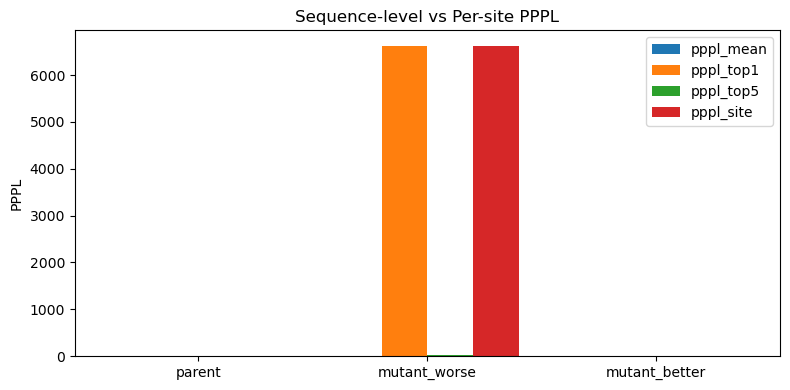

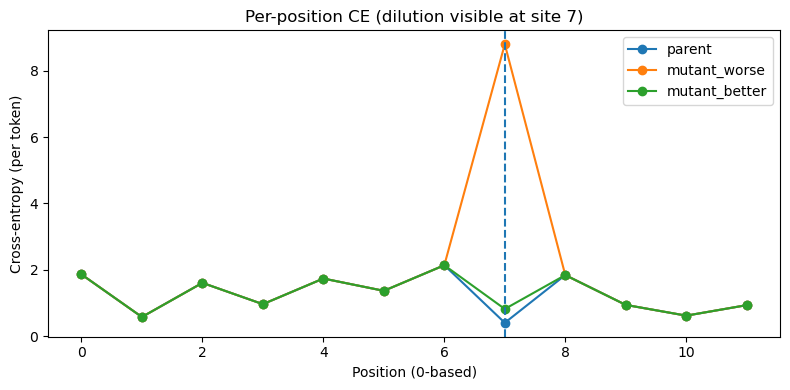

In [6]:
# toy_pppl_playground_df.py
# ------------------------------------------------------------
# Learn PPPL step-by-step:
#  - tensors -> masking -> per-token loss -> metrics
#  - convert tensors to numpy, then to pandas DataFrames
#  - plot sequence-level vs per-site behavior
#
# Run:  python toy_pppl_playground_df.py
# ------------------------------------------------------------

import numpy as np
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

# -----------------------
# Core helpers
# -----------------------
def compute_per_token_ce(tokens, logits, noncanon_tokens):
    """
    Returns:
      ce:            [L] tensor of cross-entropy per position (NaN at non-canonical sites)·
      canonical_mask:[L] bool tensor (True where scored)
    """
    noncanon = torch.tensor(noncanon_tokens, dtype=torch.long)
    # mask: positions we WILL score (canonical positions)
    # tensor([True, True, True, True, True, True, True, True, True, True, True, True])
    canonical_mask = ~torch.isin(tokens, noncanon)          # [L] bool

    # For CE we need only canonical positions (logits: [L, V], labels: [L])
    logits_seq = logits[canonical_mask]                      # [L', V]
    labels_seq = tokens[canonical_mask]                      # [L']

    # per-token CE over canonical positions
    ce_seq = F.cross_entropy(logits_seq, labels_seq, reduction="none")  # [L']

    # Put back into [L] with NaNs at non-canonical sites for easy plotting/joining
    L = tokens.shape[0]
    ce_full = torch.full((L,), float("nan"), dtype=ce_seq.dtype)
    ce_full[canonical_mask] = ce_seq
    return ce_full, canonical_mask


def compute_metrics(tokens, logits, noncanon_tokens, per_site_idx=None):
    """
    Compute:
      - pppl_mean (sequence-level)
      - pppl_top1 (sequence-level, over per-token CE)
      - pppl_top5 (sequence-level, over per-token CE)
      - pppl_site (per-site, default to first canonical site unless per_site_idx is given)

    Also returns the per-token CE and mask so we can build DataFrames/plots.
    """
    ce_full, canonical_mask = compute_per_token_ce(tokens, logits, noncanon_tokens)

    # Sequence-level metrics (only over canonical positions)
    ce_all = ce_full[canonical_mask]                       # [L']
    # mean PPPL → average model surprise over all scored sites.
    pppl_mean = float(torch.exp(ce_all.mean()).item())

    # Matching your code style: "top-k" taken over per-token CE values
    # numel is the number of elements in a tensor
    # x = torch.tensor([10, 20, 30])
    # print(x.numel())   # 3
    k1 = min(1, ce_all.numel()) 
    k5 = min(5, ce_all.numel())
    # top-1 PPPL → model surprise at its worst predicted site.
    pppl_top1 = float(torch.exp(ce_all.topk(k1).values.mean()).item())
    # top-5 PPPL → model surprise at its worst predicted site among the top 5.
    pppl_top5 = float(torch.exp(ce_all.topk(k5).values.mean()).item())

    # Per-site metric
    # tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
    valid_pos = torch.where(canonical_mask)[0]
    if valid_pos.numel() == 0:
        pppl_site = float("nan")
    else:
        if per_site_idx is None:
            j = int(valid_pos[0].item())   # default: first canonical site
        else:
            j = int(per_site_idx)
            if j not in valid_pos.tolist():
                raise ValueError(f"per_site_idx {j} is not canonical.")
        site_loss = F.cross_entropy(
            logits[j].unsqueeze(0), tokens[j].unsqueeze(0), reduction="mean"
        )
        pppl_site = float(torch.exp(site_loss).item())

    return {
        "pppl_mean": pppl_mean,
        "pppl_top1": pppl_top1,
        "pppl_top5": pppl_top5,
        "pppl_site": pppl_site,
        "ce_full": ce_full,                     # [L] tensor with NaNs at non-canonical
        "canonical_mask": canonical_mask,       # [L] bool tensor
    }


def to_numpy(x):
    """Torch tensor -> NumPy array (safe for CPU/plotting/pandas)."""
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


# -----------------------
# Build a tiny toy problem
# -----------------------
V = 22                     # vocab size (20 canonical AA + 2 non-canonical)
NONCANON = [20, 21]        # pretend these are non-canonical token IDs
L = 12                     # sequence length

# Parent tokens (canonical only: 0..19)
# tensor([ 2,  7, 16, 14,  6, 15,  0,  4, 10, 13, 18, 14])
tokens_parent = torch.randint(low=0, high=20, size=(L,), dtype=torch.long)

# Random logits, then "sharpen" true token to make model plausible
# logits_parents is a tensor with 22 elements per position, in total 12 position (because L=12)
logits_parent = torch.randn(L, V)

# Add a strong signal for the true token at each position
# 对于每一个位置i,找到其对应的真实token,然后在logits_parent[i]中增加2.5
for i in range(L):
    logits_parent[i, tokens_parent[i]] += 2.5

# Choose a mutation site (0-based)
mut_pos = 7
# 查出mut_pos =7时的token ID (从tokens_parent中取出第7个元素, 是0)
# 如果是20 或21 （noncanon),则将其替换为3，这样保证这个位置是可计算的
if tokens_parent[mut_pos].item() in NONCANON:
    tokens_parent[mut_pos] = torch.tensor(3)

# Make a single-site mutant (change AA at mut_pos)
tokens_mut = tokens_parent.clone()

# 如果原来的token是19， +1后变成0, 如果是20, 则变成1, 以此类推
# 这样保证mut_pos位置的token是可计算的 （在1-20的范围内）
new_token = (tokens_parent[mut_pos] + 1) % 20
# 替换mut_pos位置的token，相当于变成了新的氨基酸
tokens_mut[mut_pos] = new_token

# Two model attitudes about that mutation:
logits_mut_worse = logits_parent.clone()
# 对于mut_pos位置的new_token, 减少其logits值3.0
# 对于mut_pos位置的原token, 增加其logits值2.0
# 这样就使得mut_pos位置的new_token的概率变小了
# 使得mut_pos位置的原token的概率变大了
# 核心点是：softmax 只关心同一位置各个 token 之间的“相对差值”，不在乎你是否整体加了常数。
# 先加 +2.5（在每个位置的真实 token 上）目的是把“父序列”的 logits 变得更像一个训练过的模型：
# 在每个位置上，真实标签的 logit 比其他 token 高一些（更自信）。这一步是全局的、与突变无关的背景设定。
# 这里只在**突变位点 mut_pos**上做改动： 把新氨基酸 new_token 的 logit 再压低 -3.0
# 把原氨基酸（父序列那个）再抬高 +2.0
# 意义：在这个位置上，让“原氨基酸”比“新氨基酸”高很多，从而 softmax 概率明显偏向原氨基酸 → 体现“模型不喜欢这个突变”。
logits_mut_worse[mut_pos, tokens_parent[mut_pos]] += 2.0
logits_mut_worse[mut_pos, new_token] -= 3.0

# 同理，这里构造一个“更喜欢突变”的模型：
logits_mut_better = logits_parent.clone()
logits_mut_better[mut_pos, new_token] += 3.0
logits_mut_better[mut_pos, tokens_parent[mut_pos]] -= 2.0

# -----------------------
# Compute metrics
# -----------------------
parent = compute_metrics(tokens_parent, logits_parent, NONCANON, per_site_idx=None)
mut_worse = compute_metrics(tokens_mut, logits_mut_worse, NONCANON, per_site_idx=mut_pos)
mut_better = compute_metrics(tokens_mut, logits_mut_better, NONCANON, per_site_idx=mut_pos)

# -----------------------
# Build summary DataFrame (sequence-level + per-site)
# -----------------------
summary_rows = []
for name, m in [
    ("parent", parent),
    ("mutant_worse", mut_worse),
    ("mutant_better", mut_better),
]:
    summary_rows.append({
        "variant": name,
        "pppl_mean": m["pppl_mean"],
        "pppl_top1": m["pppl_top1"],
        "pppl_top5": m["pppl_top5"],
        "pppl_site": m["pppl_site"],
    })

df_summary = pd.DataFrame(summary_rows).set_index("variant")
print("\n=== Summary metrics (pandas DataFrame) ===")
print(df_summary)

# -----------------------
# Build per-position CE DataFrame (to visualize dilution)
# -----------------------
def per_position_df(name, tokens, metrics):
    ce = to_numpy(metrics["ce_full"])              # shape [L], NaNs for non-canonical
    mask = to_numpy(metrics["canonical_mask"]).astype(bool)
    return pd.DataFrame({
        "variant": name,
        "pos": np.arange(L),
        "is_canonical": mask,
        "ce": ce,
    })

df_positions = pd.concat([
    per_position_df("parent", tokens_parent, parent),
    per_position_df("mutant_worse", tokens_mut, mut_worse),
    per_position_df("mutant_better", tokens_mut, mut_better),
], ignore_index=True)

print("\n=== Per-position CE (head) ===")
print(df_positions.head())

# -----------------------
# Plot: bar chart of metrics per variant
# -----------------------
fig1, ax1 = plt.subplots(figsize=(8, 4))
# Choose which columns to show
cols = ["pppl_mean", "pppl_top1", "pppl_top5", "pppl_site"]
x = np.arange(len(df_summary.index))  # variants
width = 0.2

for i, col in enumerate(cols):
    ax1.bar(x + i*width, df_summary[col].values, width, label=col)

ax1.set_xticks(x + width * (len(cols)-1) / 2)
ax1.set_xticklabels(df_summary.index.tolist())
ax1.set_ylabel("PPPL")
ax1.set_title("Sequence-level vs Per-site PPPL")
ax1.legend()
fig1.tight_layout()

# -----------------------
# Plot: per-position CE lines (see dilution at mut_pos)
# -----------------------
fig2, ax2 = plt.subplots(figsize=(8, 4))
for name in df_positions["variant"].unique():
    sub = df_positions[df_positions["variant"] == name]
    ax2.plot(sub["pos"].values, sub["ce"].values, marker="o", label=name)

# highlight the mutated site
ax2.axvline(mut_pos, linestyle="--")
ax2.set_xlabel("Position (0-based)")
ax2.set_ylabel("Cross-entropy (per token)")
ax2.set_title(f"Per-position CE (dilution visible at site {mut_pos})")
ax2.legend()
fig2.tight_layout()

# -----------------------
# Show or save figures
# -----------------------
plt.show()

# -----------------------
# Notes on conversions (for learning):
#  - Torch -> NumPy: x.detach().cpu().numpy()
#  - NumPy -> pandas: pd.DataFrame({...})
#  - Keep per-token CE in a flat [L] vector so it's easy to join/plot by position.
# -----------------------
